# Chapter 14 — Conditional Statements and Logic

> **Prerequisites:** ch001–ch013
>
> **You will learn:**
> - The four forms of a conditional and their logical relationships
> - Why converse and inverse are not equivalent to the original
> - How to construct and verify logical arguments from conditionals
> - The role of conditions in mathematical definitions and theorems
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A **conditional statement** has the form *if P then Q* (written $P \Rightarrow Q$). It is the workhorse of mathematical reasoning: theorems, definitions, and algorithms are all conditional in structure.

From $P \Rightarrow Q$, four related statements are often considered:

| Name | Form | Logically equivalent to original? |
|------|------|-----------------------------------|
| Original | $P \Rightarrow Q$ | — |
| Converse | $Q \Rightarrow P$ | NO |
| Inverse | $\lnot P \Rightarrow \lnot Q$ | NO |
| Contrapositive | $\lnot Q \Rightarrow \lnot P$ | YES |

This is a common source of logical errors: *"if it rains, the ground is wet"* does NOT mean *"if the ground is wet, it rained"* (the converse). But it DOES mean *"if the ground is not wet, it didn't rain"* (the contrapositive).

**Common misconception:** The converse of a true statement is always true.

This is one of the most common errors in mathematical reasoning. The original and converse are independent — knowing one tells you nothing about the other.

## 2. Intuition & Mental Models

**Physical analogy:** *If the power is on, the screen lights up.* The converse — *if the screen is lit, the power is on* — is not guaranteed (the screen might have a battery). The contrapositive — *if the screen is not lit, the power is off* — follows directly. The asymmetry is physically real.

**Computational analogy:** Preconditions and postconditions in Hoare logic. `{P} code {Q}` means: if precondition P holds before running `code`, then postcondition Q holds after. This is exactly $P \Rightarrow Q$ (conditioned on what the code does). The contrapositive is: if Q doesn't hold after, then P didn't hold before (or the code is buggy). The converse ($Q \Rightarrow P$) would mean: if Q holds after, then P held before — which is NOT guaranteed.

Recall from ch013 *(Truth Tables and Logical Reasoning)*: we verified that $(A \Rightarrow B) \Leftrightarrow (\lnot B \Rightarrow \lnot A)$ is a tautology. That is the contrapositive equivalence proven.

C:\Users\user\AppData\Local\Temp\ipykernel_16836\3943724078.py:39: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16836\3943724078.py:39: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


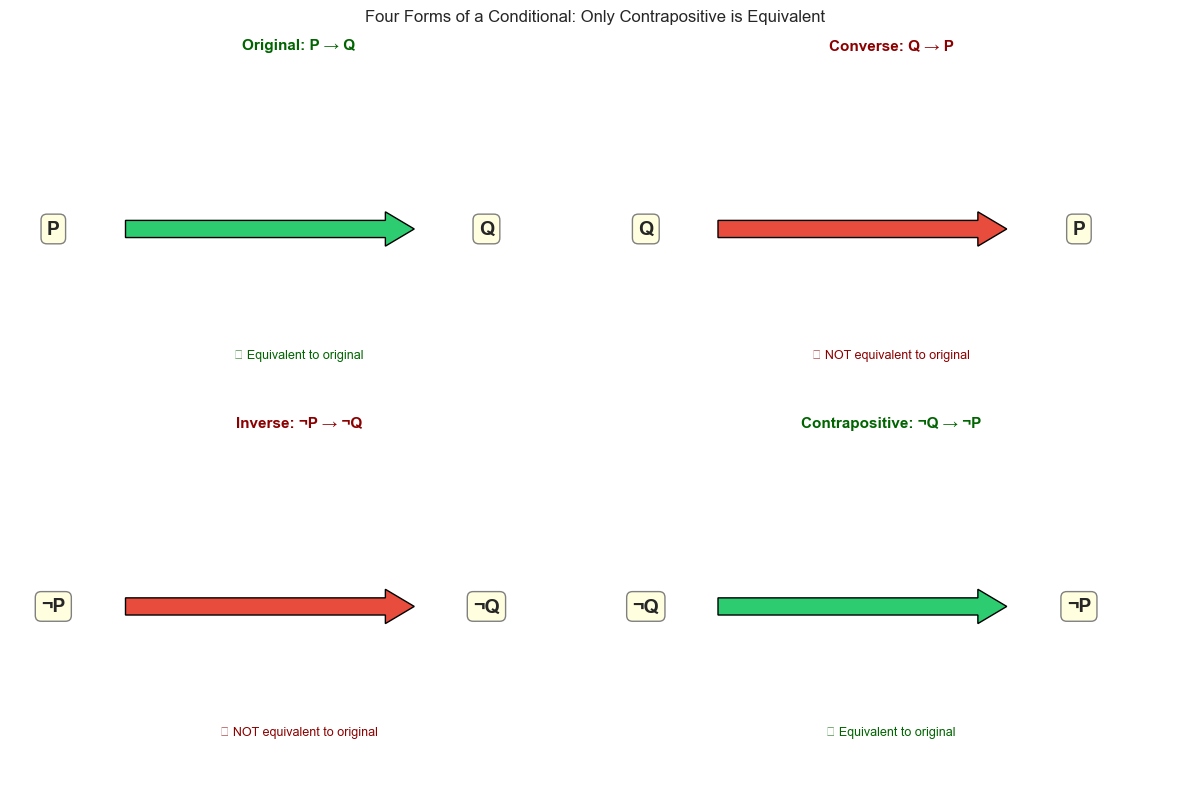

In [1]:
# --- Visualization: Four forms of a conditional ---
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

forms = [
    ('Original: P → Q', 'P', 'Q', '→', True, True),
    ('Converse: Q → P', 'Q', 'P', '→', True, False),
    ('Inverse: ¬P → ¬Q', '¬P', '¬Q', '→', True, False),
    ('Contrapositive: ¬Q → ¬P', '¬Q', '¬P', '→', True, True),
]

from itertools import product as iproduct

for ax, (title, ant, con, op, _, equiv) in zip(axes.flat, forms):
    ax.set_xlim(0, 4); ax.set_ylim(0, 3)
    ax.axis('off')
    ax.set_title(title, fontsize=11, color='darkgreen' if equiv else 'darkred',
                  fontweight='bold')
    
    # Draw the conditional as arrow
    color = '#2ecc71' if equiv else '#e74c3c'
    ax.add_patch(patches.FancyArrow(0.8, 1.5, 1.8, 0, width=0.15,
                                     head_width=0.3, head_length=0.2,
                                     facecolor=color, edgecolor='black'))
    ax.text(0.3, 1.5, ant, ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
    ax.text(3.3, 1.5, con, ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
    
    equiv_text = '✓ Equivalent to original' if equiv else '✗ NOT equivalent to original'
    ax.text(2.0, 0.4, equiv_text, ha='center', va='center', fontsize=9,
             color='darkgreen' if equiv else 'darkred')

plt.suptitle('Four Forms of a Conditional: Only Contrapositive is Equivalent', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Conditional $P \Rightarrow Q$:** False only when P is true and Q is false.

Truth table:
| P | Q | P→Q | Q→P (converse) | ¬P→¬Q (inverse) | ¬Q→¬P (contrapositive) |
|---|---|-----|----------------|-----------------|------------------------|
| F | F | T | T | T | T |
| F | T | T | F | T | T |
| T | F | F | T | F | F |
| T | T | T | T | T | T |

The original and contrapositive always agree. The converse and inverse always agree with each other but not with the original.

**Biconditional ($P \Leftrightarrow Q$):** True iff P and Q have the same truth value. This is $(P \Rightarrow Q) \land (Q \Rightarrow P)$ — both the conditional and its converse hold. When mathematicians say *"P if and only if Q"*, they mean the biconditional.

**Necessary and sufficient conditions:**
- P is *sufficient* for Q means: $P \Rightarrow Q$ (P being true is enough to guarantee Q)
- P is *necessary* for Q means: $Q \Rightarrow P$ (Q cannot be true unless P is true)
- P is *necessary and sufficient* for Q means: $P \Leftrightarrow Q$

In [2]:
# --- Implementation: Conditional analyzer ---
from itertools import product

def analyze_conditional(P_fn, Q_fn, var_names=['A', 'B']):
    """
    Given Boolean functions P and Q over the same variables,
    analyze the relationship between P and Q.
    """
    n = len(var_names)
    assignments = list(product([False, True], repeat=n))
    
    p_implies_q = all((not P_fn(*a) or Q_fn(*a)) for a in assignments)
    q_implies_p = all((not Q_fn(*a) or P_fn(*a)) for a in assignments)
    
    result = {
        'P → Q (P sufficient for Q)': p_implies_q,
        'Q → P (P necessary for Q)': q_implies_p,
        'P ↔ Q (equivalent)': p_implies_q and q_implies_p,
    }
    
    # Find counterexamples if not holding
    if not p_implies_q:
        ce = next(a for a in assignments if P_fn(*a) and not Q_fn(*a))
        result['Counterexample (P true, Q false)'] = dict(zip(var_names, ce))
    if not q_implies_p:
        ce = next(a for a in assignments if Q_fn(*a) and not P_fn(*a))
        result['Counterexample (Q true, P false)'] = dict(zip(var_names, ce))
    
    return result

# Example 1: P = 'divisible by 4', Q = 'divisible by 2'
# P ⊂ Q: every multiple of 4 is a multiple of 2, but not vice versa
print('Example: divisible by 4 vs divisible by 2 (over integers 1-30)')
P = lambda n: n % 4 == 0
Q = lambda n: n % 2 == 0
domain = range(1, 31)
p_imp_q = all(not P(n) or Q(n) for n in domain)
q_imp_p = all(not Q(n) or P(n) for n in domain)
print(f'  P→Q (mult of 4 → mult of 2): {p_imp_q}  (4 is sufficient for 2)')
print(f'  Q→P (mult of 2 → mult of 4): {q_imp_p}  (2 is NOT sufficient for 4)')
print(f'  Counterexample: n=2 is divisible by 2 but not 4')
print()

# Example 2: Two Boolean conditions
print('Example 2: P = (A and B), Q = (A or B)')
result = analyze_conditional(
    P_fn=lambda A,B: A and B,
    Q_fn=lambda A,B: A or B,
)
for k, v in result.items():
    print(f'  {k}: {v}')

Example: divisible by 4 vs divisible by 2 (over integers 1-30)
  P→Q (mult of 4 → mult of 2): True  (4 is sufficient for 2)
  Q→P (mult of 2 → mult of 4): False  (2 is NOT sufficient for 4)
  Counterexample: n=2 is divisible by 2 but not 4

Example 2: P = (A and B), Q = (A or B)
  P → Q (P sufficient for Q): True
  Q → P (P necessary for Q): False
  P ↔ Q (equivalent): False
  Counterexample (Q true, P false): {'A': False, 'B': True}


In [4]:
# --- Experiment: Common logical errors in code ---
# Hypothesis: Conditional logic errors (converse/inverse confusion) are common
# in real conditions. Demonstrate with typical programming scenarios.

def test_condition_logic():
    # Bug pattern: asserting converse when original was intended
    
    # WRONG: if sorted, then valid (converse of 'if valid, then sorted')
    def is_sorted(lst):
        return all(lst[i] <= lst[i+1] for i in range(len(lst)-1))
    
    def is_valid_data(lst):
        """A list is 'valid' if it has no negative numbers and is sorted."""        
        return all(x >= 0 for x in lst) and is_sorted(lst)
    
    test_cases = [
        [1, 2, 3, 4],      # valid AND sorted
        [1, 3, 2, 4],      # valid but NOT sorted
        [-1, 0, 1, 2],     # sorted but NOT valid (negative)
        [3, 1, 4, 1, 5],   # neither
    ]
    
    print('Condition analysis for list validation:')
    print(f'{"List":<25} {"valid":>7} {"sorted":>8} {"valid→sorted":>14} {"sorted→valid":>14}')
    print('-'*72)
    for lst in test_cases:
        v = is_valid_data(lst)
        s = is_sorted(lst)
        v_imp_s = not v or s
        s_imp_v = not s or v
        print(f'{str(lst):<25} {str(v):>7} {str(s):>8} {str(v_imp_s):>14} {str(s_imp_v):>14}')
    
    print()
    print('Conclusion: valid→sorted always holds (valid implies sorted by definition)')
    print('But sorted→valid does NOT (a sorted list can have negatives)')

test_condition_logic()

Condition analysis for list validation:
List                        valid   sorted   valid→sorted   sorted→valid
------------------------------------------------------------------------
[1, 2, 3, 4]                 True     True           True           True
[1, 3, 2, 4]                False    False           True           True
[-1, 0, 1, 2]               False     True           True          False
[3, 1, 4, 1, 5]             False    False           True           True

Conclusion: valid→sorted always holds (valid implies sorted by definition)
But sorted→valid does NOT (a sorted list can have negatives)


## 7. Exercises

**Easy 1.** State the contrapositive of: *"If a number is divisible by 6, then it is divisible by both 2 and 3."* Verify computationally that the original and contrapositive are equivalent for integers 1–100. *(Expected: both hold or both fail on every test case)*

**Easy 2.** For the conditional *"If it is a square, then it is a rectangle,"* determine whether the converse, inverse, and contrapositive are true or false. Test computationally using area/perimeter properties. *(Hint: define shapes by a single parameter and test the geometric properties)*

**Medium 1.** The statement "P is necessary and sufficient for Q" means $P \Leftrightarrow Q$. Find a mathematical example where P is sufficient but not necessary, and one where P is necessary but not sufficient, using divisibility relations on integers 1–50.

**Medium 2.** In type theory, the conditional $P \Rightarrow Q$ corresponds to a function from proofs of P to proofs of Q. Implement this correspondence: write a Python function that takes a "proof" (any object) of P and transforms it to a "proof" of Q for the specific conditional: *"If n is even, then n² is even."* The function should take an integer n (the proof that n is even, i.e., n must be even) and return n² (demonstrating n² is even).

**Hard.** Prove computationally that the following argument form is valid (hypothetical syllogism): from $P \Rightarrow Q$ and $Q \Rightarrow R$, conclude $P \Rightarrow R$. Then extend: given n conditionals $P_1 \Rightarrow P_2$, $P_2 \Rightarrow P_3$, ..., $P_{n-1} \Rightarrow P_n$, prove $P_1 \Rightarrow P_n$ using induction. Implement a function that chains n conditionals and verifies the result is valid for n=2,3,4,5.

In [6]:
# --- Mini Project: Theorem structure analyzer ---
# Many mathematical theorems are conditionals: IF [conditions] THEN [conclusion].
# Build a tool that decomposes theorem statements and checks their logical structure.

class TheoremAnalyzer:
    """
    Analyzes the logical structure of theorem-like statements.
    Stores hypotheses and conclusion, checks consistency.
    """
    def __init__(self, name):
        self.name = name
        self.hypotheses = []
        self.conclusion = None
    
    def add_hypothesis(self, desc, pred):
        self.hypotheses.append((desc, pred))
        return self
    
    def set_conclusion(self, desc, pred):
        self.conclusion = (desc, pred)
        return self
    
    def verify(self, domain, verbose=True):
        """Check if theorem holds on given domain."""        
        if self.conclusion is None:
            raise ValueError('No conclusion set')
        
        conc_desc, conc_pred = self.conclusion
        
        counterexamples = []
        for x in domain:
            hyps_hold = all(pred(x) for _, pred in self.hypotheses)
            if hyps_hold and not conc_pred(x):
                counterexamples.append(x)
        
        if verbose:
            print(f'Theorem: {self.name}')
            print(f'  Hypotheses: {[h for h,_ in self.hypotheses]}')
            print(f'  Conclusion: {conc_desc}')
            if counterexamples:
                print(f'  FAILS: counterexamples = {counterexamples[:5]}')
            else:
                print(f'  HOLDS on all {len(list(domain))} domain elements')
        return len(counterexamples) == 0

# Example: Theorem about even squares
t = TheoremAnalyzer('Square of even integer is divisible by 4')
t.add_hypothesis('n is even', lambda n: n % 2 == 0)
t.set_conclusion('n² is divisible by 4', lambda n: (n*n) % 4 == 0)
t.verify(range(-50, 51))
print()

# Example: A false theorem
t2 = TheoremAnalyzer('Square of odd integer is odd (true) then also prime?')
t2.add_hypothesis('n is odd', lambda n: n % 2 == 1)
t2.set_conclusion('n² is prime', lambda n: all(n*n % i != 0 for i in range(2, n*n)) and n*n > 1)
t2.verify(range(1, 30))

Theorem: Square of even integer is divisible by 4
  Hypotheses: ['n is even']
  Conclusion: n² is divisible by 4
  HOLDS on all 101 domain elements

Theorem: Square of odd integer is odd (true) then also prime?
  Hypotheses: ['n is odd']
  Conclusion: n² is prime
  FAILS: counterexamples = [1, 3, 5, 7, 9]


False

## 9. Chapter Summary & Connections

- A conditional $P \Rightarrow Q$ has four forms: the original, converse, inverse, and contrapositive; only the last is logically equivalent to the original
- Necessary and sufficient conditions correspond precisely to direction of implication: sufficient = $P \Rightarrow Q$, necessary = $Q \Rightarrow P$
- The biconditional $P \Leftrightarrow Q$ requires both directions: it says P and Q are logically interchangeable
- Most mathematical theorems are conditionals; decomposing them into hypotheses and conclusion is the first step in understanding or proving them

**Forward:** The conditional structure of theorems is what we will prove in ch015 — Mathematical Proof Intuition. Necessary and sufficient conditions become the core of mathematical definitions throughout the book. The contrapositive proof technique is used in ch016 — Proof by Example and Counterexample.

**Backward:** This chapter applies ch013 *(Truth Tables and Logical Reasoning)*: we use truth tables to verify the equivalence of original and contrapositive, and the non-equivalence of original and converse.